# Course Risk Prediction - Smart Course Registration System

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [2]:
DATA_DIR = os.path.join(os.getcwd(), 'Dataset')

In [3]:
#if you want to check the current working directory and the data directory, you can uncomment the following lines:
# print(f"Current working directory: {os.getcwd()}")
# print(f"Data directory: {DATA_DIR}")

# 1.) Loading the Datasets

In [4]:
## Load all required CSVs
registrations = pd.read_csv(os.path.join(DATA_DIR, "registrations.csv"))
students = pd.read_csv(os.path.join(DATA_DIR, "students.csv"))
courses = pd.read_csv(os.path.join(DATA_DIR, "courses.csv"))
prerequisites = pd.read_csv(os.path.join(DATA_DIR, "prerequisites.csv"))

## Viewing registrations.csv (our main dataset)

In [5]:
registrations.head(10)

,registration_id,student_id,section_id,course_id,semester,status,grade,registration_date,drop_date
0,1,83,1,1,Fall 2021,Completed,AA,2021-07-09,NaN
1,2,83,2,2,Fall 2021,Completed,AA,2021-07-09,NaN
2,3,83,3,3,Fall 2021,Completed,AB,2021-07-09,NaN
3,4,83,4,4,Fall 2021,Completed,AA,2021-07-09,NaN
4,5,83,5,5,Fall 2021,Completed,BB,2021-07-09,NaN
5,6,84,1,1,Fall 2021,Completed,BC,2021-07-09,NaN
6,7,84,2,2,Fall 2021,Completed,BB,2021-07-09,NaN
7,8,84,3,3,Fall 2021,Completed,BC,2021-07-09,NaN
8,9,84,4,4,Fall 2021,Completed,AB,2021-07-09,NaN
9,10,84,5,5,Fall 2021,Completed,BB,2021-07-09,NaN


In [6]:
registrations.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   registration_id    20000 non-null  int64 
 1   student_id         20000 non-null  int64 
 2   section_id         20000 non-null  int64 
 3   course_id          20000 non-null  int64 
 4   semester           20000 non-null  object
 5   status             20000 non-null  object
 6   grade              18000 non-null  object
 7   registration_date  20000 non-null  object
 8   drop_date          553 non-null    object
dtypes: int64(4), object(5)
memory usage: 1.4+ MB


In [7]:
registrations.shape

(20000, 9)

In [8]:
registrations['status'].value_counts()

status
Completed     17447
Registered     2000
Dropped         553
Name: count, dtype: int64

# 2.) Building the Feature Table
We need to join registrations with students and courses to get useful features like CGPA, credits, prerequisite grades etc.

## a.) Merge with students.csv (to get CGPA, credits completed)

In [9]:
df = registrations.merge(
    students[['student_id', 'cgpa', 'total_credits_completed']],
    on='student_id', how='left'
)
df.head()

,registration_id,student_id,section_id,course_id,semester,status,grade,registration_date,drop_date,cgpa,total_credits_completed
0,1,83,1,1,Fall 2021,Completed,AA,2021-07-09,NaN,9.17,140
1,2,83,2,2,Fall 2021,Completed,AA,2021-07-09,NaN,9.17,140
2,3,83,3,3,Fall 2021,Completed,AB,2021-07-09,NaN,9.17,140
3,4,83,4,4,Fall 2021,Completed,AA,2021-07-09,NaN,9.17,140
4,5,83,5,5,Fall 2021,Completed,BB,2021-07-09,NaN,9.17,140


## b.) Merge with courses.csv (to get course credits)

In [10]:
df = df.merge(
    courses[['course_id', 'credits']],
    on='course_id', how='left'
)
df.head()

,registration_id,student_id,section_id,course_id,semester,status,grade,registration_date,drop_date,cgpa,total_credits_completed,credits
0,1,83,1,1,Fall 2021,Completed,AA,2021-07-09,NaN,9.17,140,8
1,2,83,2,2,Fall 2021,Completed,AA,2021-07-09,NaN,9.17,140,8
2,3,83,3,3,Fall 2021,Completed,AB,2021-07-09,NaN,9.17,140,8
3,4,83,4,4,Fall 2021,Completed,AA,2021-07-09,NaN,9.17,140,8
4,5,83,5,5,Fall 2021,Completed,BB,2021-07-09,NaN,9.17,140,8


## c.) Compute course difficulty
For each course, calculate the historical average grade. Harder courses have lower average grades.

In [11]:
## grade to numeric mapping (IIT 10-point scale)
grade_map = {'AA':10, 'AB':9, 'BB':8, 'BC':7, 'CC':6, 'CD':5, 'DD':4, 'FF':0, 'W':0}

## only use completed registrations to compute difficulty
completed = df[df['status'] == 'Completed'].copy()
completed['grade_value'] = completed['grade'].map(grade_map)

## average grade per course (lower = harder)
course_difficulty = completed.groupby('course_id')['grade_value'].mean().reset_index()
course_difficulty.columns = ['course_id', 'course_avg_grade']

df = df.merge(course_difficulty, on='course_id', how='left')
df['course_avg_grade'] = df['course_avg_grade'].fillna(7.0)  ## neutral fill

df.head()

,registration_id,student_id,section_id,course_id,semester,status,grade,registration_date,drop_date,cgpa,total_credits_completed,credits,course_avg_grade
0,1,83,1,1,Fall 2021,Completed,AA,2021-07-09,NaN,9.17,140,8,7.564767
1,2,83,2,2,Fall 2021,Completed,AA,2021-07-09,NaN,9.17,140,8,7.510526
2,3,83,3,3,Fall 2021,Completed,AB,2021-07-09,NaN,9.17,140,8,6.973822
3,4,83,4,4,Fall 2021,Completed,AA,2021-07-09,NaN,9.17,140,8,7.487047
4,5,83,5,5,Fall 2021,Completed,BB,2021-07-09,NaN,9.17,140,8,6.994845


## d.) Compute prerequisite grade
For each registration, find if the course has a prerequisite and what grade the student got in it.

In [12]:
## build prerequisite lookup: course_id -> prereq_course_id
prereq_map = dict(zip(prerequisites['course_id'], prerequisites['prerequisite_course_id']))

## build student grade lookup: (student_id, course_id) -> grade_value
completed['grade_value'] = completed['grade'].map(grade_map)
grade_lookup = completed.set_index(['student_id', 'course_id'])['grade_value'].to_dict()

## for each row, find the prereq grade
def get_prereq_grade(row):
    prereq_cid = prereq_map.get(row['course_id'])
    if prereq_cid is None:
        return 7  ## no prerequisite exists, use neutral value
    return grade_lookup.get((row['student_id'], prereq_cid), 7)

df['prereq_grade'] = df.apply(get_prereq_grade, axis=1)
df.head()

,registration_id,student_id,section_id,course_id,semester,status,grade,registration_date,drop_date,cgpa,total_credits_completed,credits,course_avg_grade,prereq_grade
0,1,83,1,1,Fall 2021,Completed,AA,2021-07-09,NaN,9.17,140,8,7.564767,7
1,2,83,2,2,Fall 2021,Completed,AA,2021-07-09,NaN,9.17,140,8,7.510526,7
2,3,83,3,3,Fall 2021,Completed,AB,2021-07-09,NaN,9.17,140,8,6.973822,7
3,4,83,4,4,Fall 2021,Completed,AA,2021-07-09,NaN,9.17,140,8,7.487047,7
4,5,83,5,5,Fall 2021,Completed,BB,2021-07-09,NaN,9.17,140,8,6.994845,7


## e.) View the merged dataset

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   registration_id          20000 non-null  int64  
 1   student_id               20000 non-null  int64  
 2   section_id               20000 non-null  int64  
 3   course_id                20000 non-null  int64  
 4   semester                 20000 non-null  object 
 5   status                   20000 non-null  object 
 6   grade                    18000 non-null  object 
 7   registration_date        20000 non-null  object 
 8   drop_date                553 non-null    object 
 9   cgpa                     20000 non-null  float64
 10  total_credits_completed  20000 non-null  int64  
 11  credits                  20000 non-null  int64  
 12  course_avg_grade         20000 non-null  float64
 13  prereq_grade             20000 non-null  int64  
dtypes: float64(2), int64(7

In [14]:
df.describe()

,registration_id,student_id,section_id,course_id,cgpa,total_credits_completed,credits,course_avg_grade,prereq_grade
count,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000
mean,10000.500000,664.500000,494.650100,84.452700,6.948200,132.618000,7.820000,7.300545,7.066300
std,5773.647028,344.869826,256.310217,47.412035,2.197043,40.487579,1.499237,0.291710,1.187803
min,1.000000,83.000000,1.000000,1.000000,0.000000,0.000000,6.000000,5.909091,0.000000
25%,5000.750000,372.750000,293.750000,51.000000,6.200000,140.000000,8.000000,7.104167,7.000000
50%,10000.500000,662.500000,501.500000,85.500000,7.410000,148.000000,8.000000,7.310881,7.000000
75%,15000.250000,952.250000,716.250000,120.250000,8.400000,156.000000,8.000000,7.469072,7.000000
max,20000.000000,1282.000000,923.000000,166.000000,9.900000,156.000000,14.000000,8.666667,10.000000


# 3.) Handling Dropped Students (Outliers)
Dropped students got a 'W' grade but their CGPA is not necessarily bad. They may have dropped for personal reasons, not academic struggle. Let's check this.

In [15]:
## compare CGPA of dropped vs completed students
dropped = df[df['status'] == 'Dropped']
completed_students = df[df['status'] == 'Completed']

print("Dropped students CGPA stats:")
print(dropped['cgpa'].describe())
print()
print("Completed students CGPA stats:")
print(completed_students['cgpa'].describe())

Dropped students CGPA stats:
count    553.000000
mean       7.322857
std        1.498845
min        0.700000
25%        6.410000
50%        7.490000
75%        8.460000
max        9.860000
Name: cgpa, dtype: float64

Completed students CGPA stats:
count    17447.000000
mean         7.314900
std          1.558513
min          0.700000
25%          6.460000
50%          7.500000
75%          8.475000
max          9.900000
Name: cgpa, dtype: float64


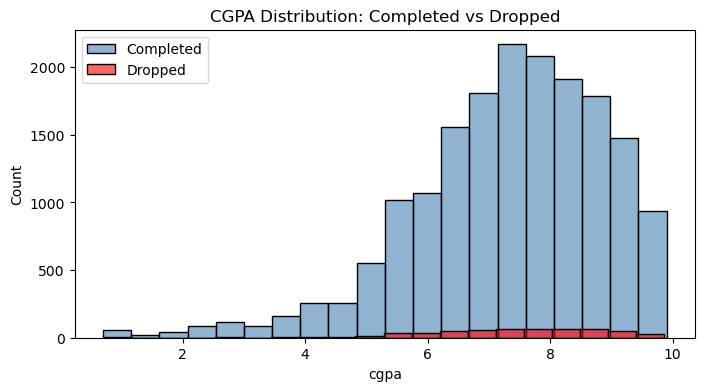

In [16]:
## visualize: CGPA distribution of dropped vs completed
fig, ax = plt.subplots(1, 1, figsize=(8, 4))
sns.histplot(data=completed_students, x='cgpa', label='Completed', color='steelblue', alpha=0.6, bins=20, ax=ax)
sns.histplot(data=dropped, x='cgpa', label='Dropped', color='red', alpha=0.6, bins=20, ax=ax)
ax.legend()
ax.set_title('CGPA Distribution: Completed vs Dropped')
plt.show()

In [17]:
## Conclusion: Dropped students have similar CGPA range as completed students
## So "Dropped" does NOT mean "High Risk academically"
## We remove them as outliers — they are not useful for predicting academic risk

df = df[df['status'] != 'Dropped']
print("After removing dropped students:", df.shape)
print(df['status'].value_counts())

After removing dropped students: (19447, 14)
status
Completed     17447
Registered     2000
Name: count, dtype: int64


# 4.) Create the Risk Label (Target Variable)
Based on the grade received:
- **0 = Low Risk** (AA, AB, BB)
- **1 = Medium Risk** (BC, CC) 
- **2 = High Risk** (CD, DD, FF)

In [18]:
def grade_to_risk(grade):
    if grade in ('AA', 'AB', 'BB'):
        return 0  ## Low Risk
    elif grade in ('BC', 'CC'):
        return 1  ## Medium Risk
    elif grade in ('CD', 'DD', 'FF'):
        return 2  ## High Risk
    else:
        return -1  ## ongoing (no grade yet)

df['risk_label'] = df['grade'].apply(grade_to_risk)
df['risk_label'].value_counts()

risk_label
 0    8567
 1    6432
 2    2448
-1    2000
Name: count, dtype: int64

# 5.) Separate Training Data and Prediction Data
- **Training** = Completed registrations (have grades, so we know the risk)
- **Prediction** = Registered/ongoing (no grade yet, model will predict)

In [19]:
df_train = df[df['status'] == 'Completed'].copy()
df_predict = df[df['status'] == 'Registered'].copy()

print("Training rows:  ", len(df_train))
print("Prediction rows:", len(df_predict))

Training rows:   17447
Prediction rows: 2000


## Filter: only predict for students above 1st year
1st year students have 0 credits completed and CGPA = 0, so the model has no history to learn from.

In [20]:
## remove 1st year students (0 credits completed)
df_train = df_train[df_train['total_credits_completed'] > 0]
df_predict = df_predict[df_predict['total_credits_completed'] > 0]

print("After filtering 1st year students:")
print("Training rows:  ", len(df_train))
print("Prediction rows:", len(df_predict))

After filtering 1st year students:
Training rows:   17447
Prediction rows: 1000


# 6.) Select Features and Drop ID Columns

In [21]:
## keep only the feature columns and target
feature_cols = ['cgpa', 'total_credits_completed', 'credits', 'course_avg_grade', 'prereq_grade']

x = df_train[feature_cols]
y = df_train['risk_label']

print("Features:")
print(x.head())
print()
print("Target:")
print(y.value_counts())

Features:
   cgpa  total_credits_completed  credits  course_avg_grade  prereq_grade
0  9.17                      140        8          7.564767             7
1  9.17                      140        8          7.510526             7
2  9.17                      140        8          6.973822             7
3  9.17                      140        8          7.487047             7
4  9.17                      140        8          6.994845             7

Target:
risk_label
0    8567
1    6432
2    2448
Name: count, dtype: int64


# 7.) E.D.A (Exploratory Data Analysis)

### a.) Class balance test

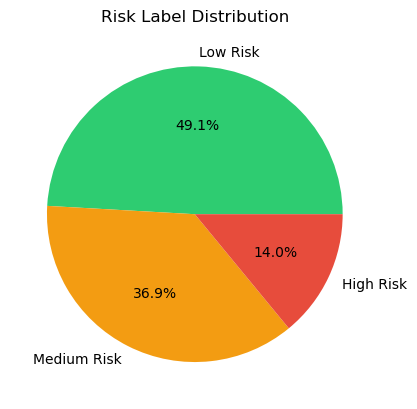

In [22]:
classes_count = y.value_counts().sort_index()
plt.pie(classes_count, labels=["Low Risk", "Medium Risk", "High Risk"],
        autopct="%1.1f%%", colors=["#2ecc71", "#f39c12", "#e74c3c"])
plt.title("Risk Label Distribution")
plt.show()

### b.) Pairplot

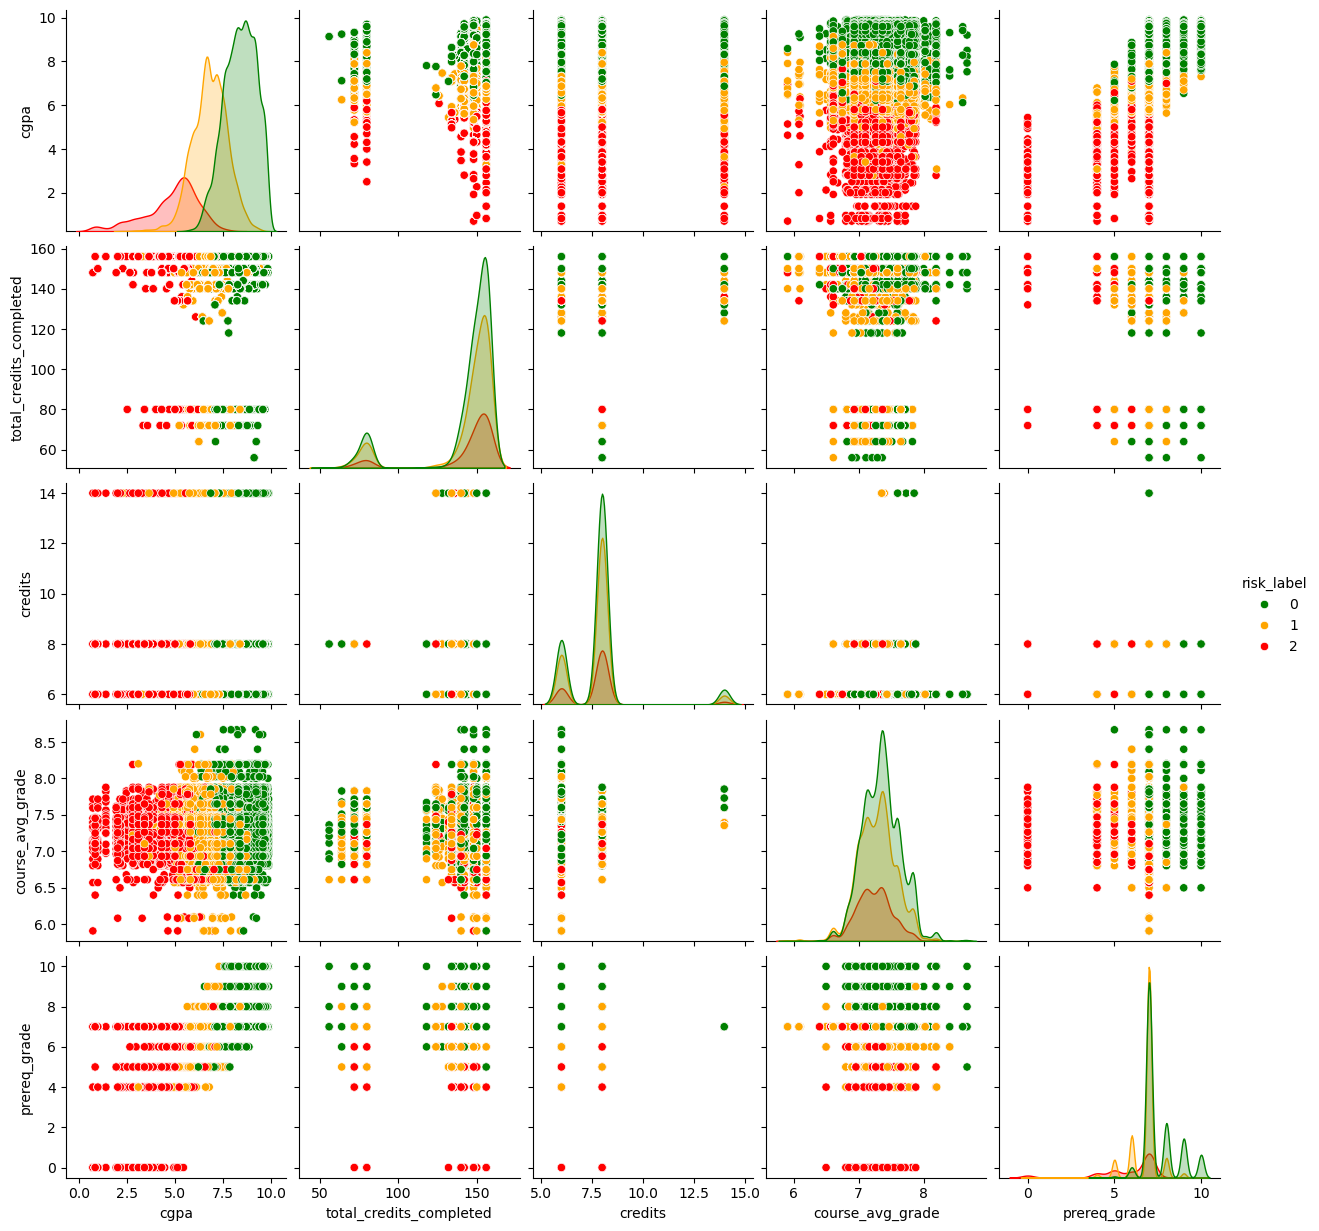

In [23]:
plot_df = df_train[feature_cols + ['risk_label']].copy()
sns.pairplot(plot_df, hue='risk_label', palette={0:'green', 1:'orange', 2:'red'})
plt.show()

### c.) Correlation heatmap

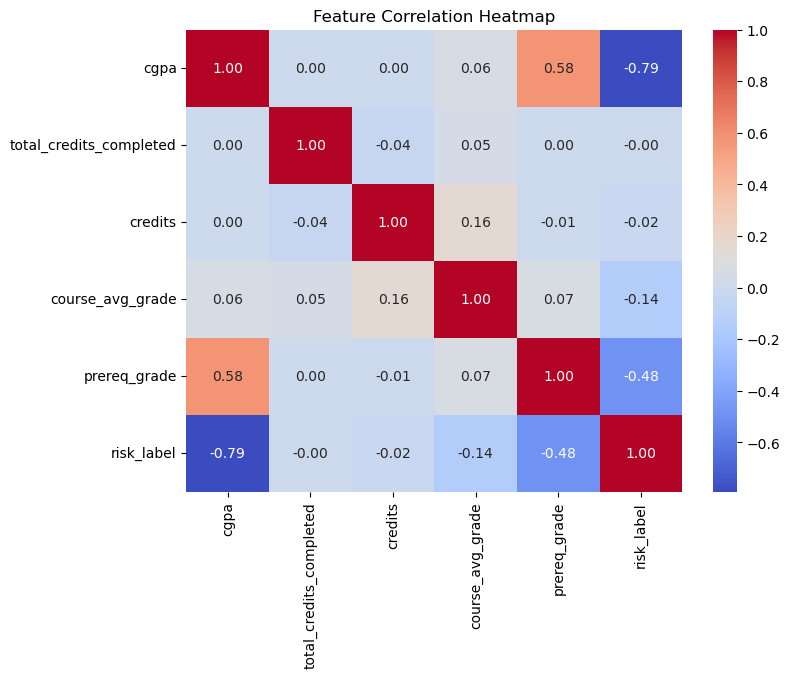

In [24]:
corr_matrix = df_train[feature_cols + ['risk_label']].corr()
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Feature Correlation Heatmap")
plt.show()

### d.) CGPA vs Risk

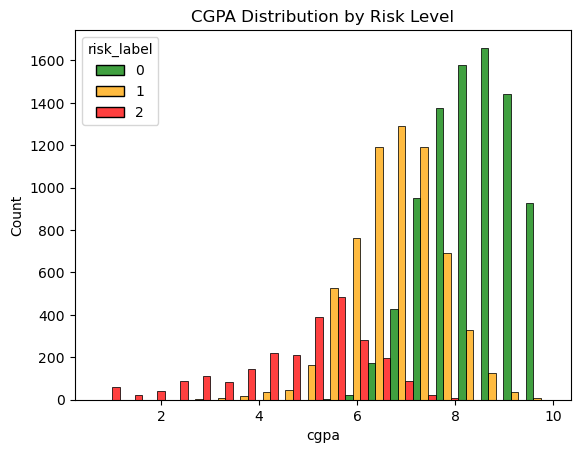

In [25]:
sns.histplot(data=df_train, x='cgpa', hue='risk_label', bins=20, multiple='dodge',
             palette={0:'green', 1:'orange', 2:'red'})
plt.title('CGPA Distribution by Risk Level')
plt.show()

### e.) Prerequisite Grade vs Risk

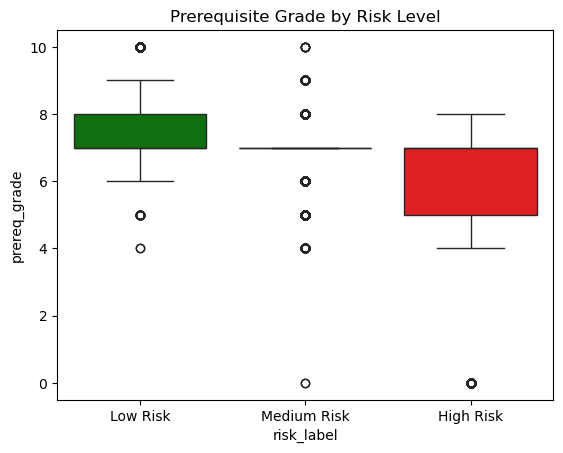

In [26]:
sns.boxplot(
    data=df_train,
    x='risk_label',
    y='prereq_grade',
    hue='risk_label',
    palette={0: 'green', 1: 'orange', 2: 'red'},
    legend=False
)

plt.xticks([0, 1, 2], ['Low Risk', 'Medium Risk', 'High Risk'])
plt.title('Prerequisite Grade by Risk Level')
plt.show()

# 8.) Train-Test Split & Feature Scaling

In [27]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

print("x_train shape:", x_train.shape)
print("x_test shape: ", x_test.shape)

x_train shape: (13957, 5)
x_test shape:  (3490, 5)


# 9.) Model Fitting

In [28]:
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

In [29]:
# Logistic Regression

from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(max_iter=1000)
log_model.fit(x_train_scaled, y_train)
y_pred = log_model.predict(x_test_scaled)

print("Logistic Regression Model")
print("Precision: ", precision_score(y_test, y_pred, average='weighted'))
print("Recall:    ", recall_score(y_test, y_pred, average='weighted'))
print("F1 score:  ", f1_score(y_test, y_pred, average='weighted'))
print("Accuracy:  ", accuracy_score(y_test, y_pred))
print("CM:\n", confusion_matrix(y_test, y_pred))

Logistic Regression Model
Precision:  0.7759357094939778
Recall:     0.7713467048710602
F1 score:   0.7704561574080614
Accuracy:   0.7713467048710602
CM:
 [[1432  248    0]
 [ 288  953   60]
 [   1  201  307]]


In [30]:
# KNN

from sklearn.neighbors import KNeighborsClassifier

knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(x_train_scaled, y_train)
y_pred = knn_model.predict(x_test_scaled)

print("KNN Model")
print("Precision: ", precision_score(y_test, y_pred, average='weighted'))
print("Recall:    ", recall_score(y_test, y_pred, average='weighted'))
print("F1 score:  ", f1_score(y_test, y_pred, average='weighted'))
print("Accuracy:  ", accuracy_score(y_test, y_pred))
print("CM:\n", confusion_matrix(y_test, y_pred))

KNN Model
Precision:  0.7313204913914725
Recall:     0.7315186246418338
F1 score:   0.7299372271290312
Accuracy:   0.7315186246418338
CM:
 [[1399  278    3]
 [ 356  848   97]
 [   5  198  306]]


In [31]:
# Naive Bayes

from sklearn.naive_bayes import GaussianNB

nb_model = GaussianNB()
nb_model.fit(x_train_scaled, y_train)
y_pred = nb_model.predict(x_test_scaled)

print("Naive Bayes Model")
print("Precision: ", precision_score(y_test, y_pred, average='weighted'))
print("Recall:    ", recall_score(y_test, y_pred, average='weighted'))
print("F1 score:  ", f1_score(y_test, y_pred, average='weighted'))
print("Accuracy:  ", accuracy_score(y_test, y_pred))
print("CM:\n", confusion_matrix(y_test, y_pred))

Naive Bayes Model
Precision:  0.7600734595664798
Recall:     0.7512893982808023
F1 score:   0.7504487734467441
Accuracy:   0.7512893982808023
CM:
 [[1385  293    2]
 [ 256  972   73]
 [   0  244  265]]


In [32]:
# Random Forest

from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(x_train_scaled, y_train)
y_pred = rf_model.predict(x_test_scaled)

print("Random Forest Model")
print("Precision: ", precision_score(y_test, y_pred, average='weighted'))
print("Recall:    ", recall_score(y_test, y_pred, average='weighted'))
print("F1 score:  ", f1_score(y_test, y_pred, average='weighted'))
print("Accuracy:  ", accuracy_score(y_test, y_pred))
print("CM:\n", confusion_matrix(y_test, y_pred))

Random Forest Model
Precision:  0.720752293661776
Recall:     0.7214899713467049
F1 score:   0.7200919610205538
Accuracy:   0.7214899713467049
CM:
 [[1385  290    5]
 [ 346  837  118]
 [   6  207  296]]


# 10. Feature Importance for Random Forest Model

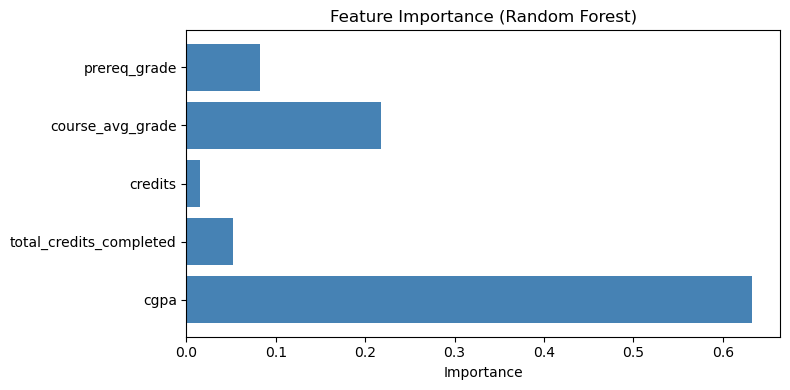

In [33]:
## from the best model (Random Forest)
importances = rf_model.feature_importances_

plt.figure(figsize=(8, 4))
plt.barh(feature_cols, importances, color='steelblue')
plt.xlabel('Importance')
plt.title('Feature Importance (Random Forest)')
plt.tight_layout()
plt.show()